Training Network on Task A...
Initial Task A Accuracy: 99.00%

Analyzing essential weights using Fisher Information...

EVALUATION ON RETENTION OF TASK A
Task A Accuracy before Task B : 99.0%
Naive Fine-Tuning (Standard)  : 56.0%
Consolidated Model (EWC)     : 64.0%


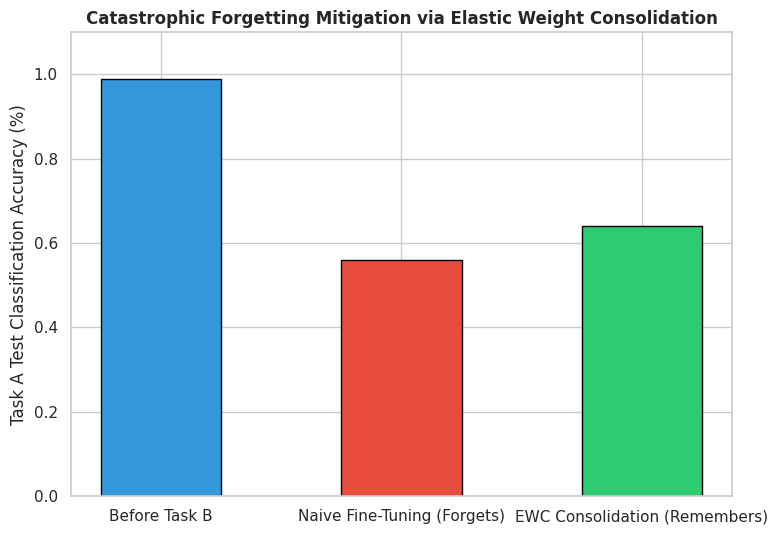

In [ ]:
# ==========================================
# Setup
# ==========================================

import os  # system tools
import warnings  # silence warnings
import numpy as np  # fast math
import tensorflow as tf  # deep learning
from tensorflow.keras import layers, Model  # model builders
import matplotlib.pyplot as plt  # plot graphs
import seaborn as sns  # plot styling

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # hide tf logs
warnings.filterwarnings('ignore')  # silence warnings

# Set random seed for reproducibility
np.random.seed(42)  # seed numpy
tf.random.set_seed(42)  # seed tensorflow

# ==========================================
# Data Generation (Task A vs Task B)
# ==========================================

# Task A dataset: predict if coordinate sum is positive
x_train_A = np.random.uniform(-2, 2, (300, 2)).astype('float32')  # A features
y_train_A = (x_train_A[:, 0] + x_train_A[:, 1] > 0).astype('int32')  # A targets
x_test_A = np.random.uniform(-2, 2, (100, 2)).astype('float32')  # A test features
y_test_A = (x_test_A[:, 0] + x_test_A[:, 1] > 0).astype('int32')  # A test targets

# Task B dataset: predict if coordinates lie within a circle (concept shift)
x_train_B = np.random.uniform(-2, 2, (300, 2)).astype('float32')  # B features
y_train_B = (np.sqrt(x_train_B[:, 0]**2 + x_train_B[:, 1]**2) < 1.0).astype('int32')  # B targets
x_test_B = np.random.uniform(-2, 2, (100, 2)).astype('float32')  # B test features
y_test_B = (np.sqrt(x_test_B[:, 0]**2 + x_test_B[:, 1]**2) < 1.0).astype('int32')  # B test targets

# ==========================================
# MLP Architecture
# ==========================================

class ContinualMLP(Model):  # multi-task classifier
    def __init__(self):
        super().__init__()
        self.d1 = layers.Dense(32, activation='relu')  # layer 1
        self.d2 = layers.Dense(32, activation='relu')  # layer 2
        self.out = layers.Dense(2)  # output logits

    def call(self, x):
        x = self.d1(x)  # pass layer 1
        x = self.d2(x)  # pass layer 2
        return self.out(x)  # return logits

# ==========================================
# Step 1: Train Standard Model on Task A
# ==========================================

model_std = ContinualMLP()  # init model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)  # standard optimizer
_ = model_std(x_train_A[:1])  # trigger input build

print("Training Network on Task A...")  # status log
for epoch in range(100):  # training loop
    with tf.GradientTape() as tape:  # track operations
        logits = model_std(x_train_A)  # forward pass
        loss = tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(y_train_A, logits, from_logits=True))  # classification loss
    grads = tape.gradient(loss, model_std.trainable_variables)  # get gradients
    optimizer.apply_gradients(zip(grads, model_std.trainable_variables))  # update weights

acc_A_init = np.mean(np.argmax(model_std(x_test_A), axis=1) == y_test_A)  # score accuracy
print(f"Initial Task A Accuracy: {acc_A_init * 100:.2f}%")

# ==========================================
# Step 2: Compute Fisher Information & Store Optimal Weights
# ==========================================

print("\nAnalyzing essential weights using Fisher Information...")  # status log
variables = model_std.trainable_variables  # fetch variables
optimal_weights = [tf.identity(v) for v in variables]  # clone optimal values
fisher_diags = [tf.zeros_like(v) for v in variables]  # init fisher diag matrix

# Calculate first-order derivative square expectations (Fisher diags)
for i in range(len(x_train_A)):
    x_val = x_train_A[i:i+1]  # get single sample
    with tf.GradientTape() as tape:
        logits = model_std(x_val)  # forward pass
        prob = tf.nn.log_softmax(logits)  # log likelihood
        loss = prob[0, y_train_A[i]]  # target likelihood
    grads = tape.gradient(loss, variables)  # gradient vectors
    for g_idx, g in enumerate(grads):
        if g is not None:
            fisher_diags[g_idx] += tf.square(g) / len(x_train_A)  # aggregate squared gradients

# ==========================================
# Step 3: Clone Model for EWC Comparison
# ==========================================

model_ewc = ContinualMLP()  # init ewc model
_ = model_ewc(x_train_A[:1])  # build ewc inputs
for v_dest, v_src in zip(model_ewc.trainable_variables, model_std.trainable_variables):
    v_dest.assign(v_src)  # transfer optimal weights

# ==========================================
# Step 4: Train Standard vs. EWC on Task B
# ==========================================

# A. Train Standard Model (Naive Fine-Tuning)
optimizer_sa_B = tf.keras.optimizers.Adam(learning_rate=0.01)  # standard task b optimizer
for epoch in range(100):
    with tf.GradientTape() as tape:
        logits = model_std(x_train_B)  # forward pass
        loss = tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(y_train_B, logits, from_logits=True))  # loss
    grads = tape.gradient(loss, model_std.trainable_variables)  # get grads
    optimizer_sa_B.apply_gradients(zip(grads, model_std.trainable_variables))  # update standard model

# B. Train EWC Model (Consolidation Penalty)
optimizer_ewc_B = tf.keras.optimizers.Adam(learning_rate=0.01)  # ewc task b optimizer
lam = 15000.0  # ewc penalty weight (stiffness factor)

for epoch in range(100):
    with tf.GradientTape() as tape:
        logits = model_ewc(x_train_B)  # forward pass
        loss_task = tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(y_train_B, logits, from_logits=True))  # b loss

        # Calculate quadratic constraint: Sum [ Fisher * (current_weight - optimal_weight_A)^2 ]
        ewc_penalty = 0.0
        for f, w_curr, w_opt in zip(fisher_diags, model_ewc.trainable_variables, optimal_weights):
            ewc_penalty += tf.reduce_sum(f * tf.square(w_curr - w_opt))

        loss = loss_task + (lam / 2.0) * ewc_penalty  # aggregate total consolidated loss
    grads = tape.gradient(loss, model_ewc.trainable_variables)  # get grads
    optimizer_ewc_B.apply_gradients(zip(grads, model_ewc.trainable_variables))  # update ewc model

# ==========================================
# Evaluation & Plot Results
# ==========================================

# Evaluate final accuracies on Task A after learning Task B
acc_A_sa_after = np.mean(np.argmax(model_std(x_test_A), axis=1) == y_test_A)
acc_A_ewc_after = np.mean(np.argmax(model_ewc(x_test_A), axis=1) == y_test_A)

print("\n=====================================")
print("EVALUATION ON RETENTION OF TASK A")
print("=====================================")
print(f"Task A Accuracy before Task B : {acc_A_init * 100:.1f}%")
print(f"Naive Fine-Tuning (Standard)  : {acc_A_sa_after * 100:.1f}%")
print(f"Consolidated Model (EWC)     : {acc_A_ewc_after * 100:.1f}%")
print("=====================================")

# Plot comparative performance bar chart
sns.set_theme(style="whitegrid")  # set theme
plt.figure(figsize=(8, 5.5))  # canvas size
categories = ['Before Task B', 'Naive Fine-Tuning (Forgets)', 'EWC Consolidation (Remembers)']
accuracies = [acc_A_init, acc_A_sa_after, acc_A_ewc_after]
plt.bar(categories, accuracies, color=['#3498db', '#e74c3c', '#2ecc71'], width=0.5, edgecolor='black')  # draw bars
plt.ylabel('Task A Test Classification Accuracy (%)')  # y label
plt.ylim(0, 1.1)  # bounds
plt.title('Catastrophic Forgetting Mitigation via Elastic Weight Consolidation', fontsize=12, fontweight='bold')  # plot title
plt.tight_layout()  # fit layout
plt.show()  # display comparison plot